In [12]:
# ============================================================
# PHASE 4: Preprocessing Pipeline
# Malaria Cell Classifier — Thrive Plus Capstone
# ============================================================

import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch
import torchvision
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import warnings
warnings.filterwarnings('ignore')

# Check if GPU is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
print(f"PyTorch version: {torch.__version__}")
print(f"Torchvision version: {torchvision.__version__}")

Device: cuda
PyTorch version: 2.11.0+cu128
Torchvision version: 0.26.0+cu128


In [13]:
# Redownload dataset if session restarted
if not os.path.exists('malaria_data'):
    from google.colab import files
    print("Upload your kaggle.json file:")
    files.upload()

    os.makedirs('/root/.config/kaggle', exist_ok=True)
    os.system('cp kaggle.json /root/.config/kaggle/')
    os.system('chmod 600 /root/.config/kaggle/kaggle.json')
    os.system('pip install kaggle -q')
    os.system('kaggle datasets download -d iarunava/cell-images-for-detecting-malaria')

    import zipfile
    with zipfile.ZipFile('cell-images-for-detecting-malaria.zip', 'r') as zip_ref:
        zip_ref.extractall('malaria_data')
    print("Dataset ready ✅")
else:
    print("Dataset already available ✅")

Dataset already available ✅


In [14]:
# ============================================================
# IMAGE SIZE: 224x224 — standard for pretrained models
# (ResNet18 and MobileNetV2 were both trained on 224x224)
# ============================================================

IMAGE_SIZE = 224

# --- TRAINING TRANSFORMS (with augmentation) ---
# Augmentation only applies to training data
# It creates artificial variety to prevent overfitting
train_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),   # Resize to 224x224
    transforms.RandomHorizontalFlip(p=0.5),         # Flip left-right randomly
    transforms.RandomVerticalFlip(p=0.3),           # Flip up-down randomly
    transforms.RandomRotation(degrees=15),           # Rotate up to 15 degrees
    transforms.ColorJitter(                          # Random color changes
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),
    transforms.ToTensor(),                           # Convert to tensor [0,1]
    transforms.Normalize(                            # Normalize with ImageNet stats
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# --- VALIDATION & TEST TRANSFORMS (no augmentation) ---
# We never augment validation/test data
# We need real, unmodified images to evaluate true performance
val_test_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("Transforms defined ✅")
print(f"\nTraining transforms:   Resize + Augmentation + Normalize")
print(f"Validation transforms: Resize + Normalize only")

Transforms defined ✅

Training transforms:   Resize + Augmentation + Normalize
Validation transforms: Resize + Normalize only


In [15]:
# ============================================================
# DATASET SPLIT: 70% Train / 15% Validation / 15% Test
# ============================================================

DATA_DIR = 'malaria_data/cell_images'

# Load full dataset first (we'll apply transforms after splitting)
full_dataset = datasets.ImageFolder(root=DATA_DIR, transform=val_test_transforms)

# Dataset size
total_size      = len(full_dataset)
train_size      = int(0.70 * total_size)  # 70%
val_size        = int(0.15 * total_size)  # 15%
test_size       = total_size - train_size - val_size  # remaining 15%

# Split randomly
torch.manual_seed(42)  # For reproducibility
train_dataset, val_dataset, test_dataset = random_split(
    full_dataset, [train_size, val_size, test_size]
)

# Apply augmentation transforms to training set only
train_dataset.dataset.transform = train_transforms

print("=" * 45)
print("   DATASET SPLIT SUMMARY")
print("=" * 45)
print(f"Total images:      {total_size:,}")
print(f"Training set:      {train_size:,}  (70%)")
print(f"Validation set:    {val_size:,}   (15%)")
print(f"Test set:          {test_size:,}   (15%)")
print("=" * 45)
print(f"\nClass mapping: {full_dataset.class_to_idx}")

   DATASET SPLIT SUMMARY
Total images:      27,558
Training set:      19,290  (70%)
Validation set:    4,133   (15%)
Test set:          4,135   (15%)

Class mapping: {'Parasitized': 0, 'Uninfected': 1}


In [16]:
# ============================================================
# DATALOADERS — Feed batches of images to the model
# Batch size 32: good balance of speed and memory
# ============================================================

BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,       # Shuffle training data every epoch
    num_workers=2,      # Parallel loading
    pin_memory=True     # Faster GPU transfer
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,      # Never shuffle val/test
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("DataLoaders created ✅")
print(f"\nBatch size:          {BATCH_SIZE}")
print(f"Training batches:    {len(train_loader)}")
print(f"Validation batches:  {len(val_loader)}")
print(f"Test batches:        {len(test_loader)}")

DataLoaders created ✅

Batch size:          32
Training batches:    603
Validation batches:  130
Test batches:        130


In [17]:
# Grab one batch and inspect it
images, labels = next(iter(train_loader))

print("=" * 45)
print("   BATCH VERIFICATION")
print("=" * 45)
print(f"Batch image shape:  {images.shape}")
print(f"  → {BATCH_SIZE} images, 3 channels (RGB), 224x224px")
print(f"Batch label shape:  {labels.shape}")
print(f"Label values:       {labels[:8].tolist()}")
print(f"  → 0 = Parasitized, 1 = Uninfected")
print(f"Pixel value range:  [{images.min():.2f}, {images.max():.2f}]")
print(f"  → Normalized (not 0-255 anymore)")
print("=" * 45)
print("✅ Pipeline is working correctly!")

   BATCH VERIFICATION
Batch image shape:  torch.Size([32, 3, 224, 224])
  → 32 images, 3 channels (RGB), 224x224px
Batch label shape:  torch.Size([32])
Label values:       [0, 1, 1, 1, 0, 1, 0, 0]
  → 0 = Parasitized, 1 = Uninfected
Pixel value range:  [-2.12, 2.47]
  → Normalized (not 0-255 anymore)
✅ Pipeline is working correctly!


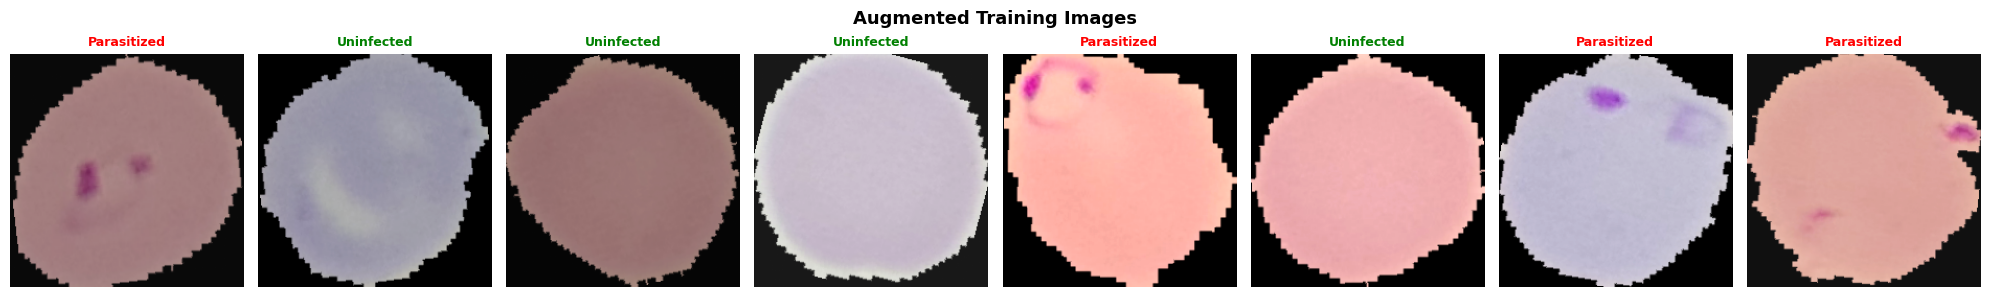

Augmented samples visualized ✅


In [18]:
# Show what augmented training images look like
classes = ['Parasitized', 'Uninfected']

fig, axes = plt.subplots(1, 8, figsize=(20, 3))
fig.suptitle('Augmented Training Images', fontsize=13, fontweight='bold')

# Denormalize for display
mean = torch.tensor([0.485, 0.456, 0.406])
std  = torch.tensor([0.229, 0.224, 0.225])

for i in range(8):
    img = images[i].clone()
    img = img * std[:, None, None] + mean[:, None, None]
    img = img.permute(1, 2, 0).numpy()
    img = np.clip(img, 0, 1)

    label = labels[i].item()
    color = 'red' if label == 0 else 'green'

    axes[i].imshow(img)
    axes[i].axis('off')
    axes[i].set_title(classes[label], color=color, fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('results_augmented_samples.png', dpi=150, bbox_inches='tight')
plt.show()
print("Augmented samples visualized ✅")

In [21]:
print("""
╔══════════════════════════════════════════════════════╗
║         PREPROCESSING PIPELINE SUMMARY               ║
╠══════════════════════════════════════════════════════╣
║                                                      ║
║  IMAGE SIZE:     224 x 224 px (RGB)                  ║
║                                                      ║
║  SPLIT:          70% Train / 15% Val / 15% Test      ║
║                                                      ║
║  AUGMENTATION (train only):                          ║
║    • Random horizontal flip (50% chance)             ║
║    • Random vertical flip (30% chance)               ║
║    • Random rotation (±15 degrees)                   ║
║    • Color jitter (brightness/contrast/saturation)   ║
║                                                      ║
║  NORMALIZATION:                                      ║
║    • Mean: [0.485, 0.456, 0.406]                     ║
║    • Std:  [0.229, 0.224, 0.225]                     ║
║    • ImageNet statistics (standard for transfer      ║
║      learning with pretrained models)                ║
║                                                      ║
║  BATCH SIZE:     32                                  ║
║  DEVICE:         GPU (T4)                            ║
║                                                      ║
╚══════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════╗
║         PREPROCESSING PIPELINE SUMMARY               ║
╠══════════════════════════════════════════════════════╣
║                                                      ║
║  IMAGE SIZE:     224 x 224 px (RGB)                  ║
║                                                      ║
║  SPLIT:          70% Train / 15% Val / 15% Test      ║
║                                                      ║
║  AUGMENTATION (train only):                          ║
║    • Random horizontal flip (50% chance)             ║
║    • Random vertical flip (30% chance)               ║
║    • Random rotation (±15 degrees)                   ║
║    • Color jitter (brightness/contrast/saturation)   ║
║                                                      ║
║  NORMALIZATION:                                      ║
║    • Mean: [0.485, 0.456, 0.406]                     ║
║    • Std:  [0.229, 0.224, 0.225]                     ║
║    • ImageNet statistics (st

In [19]:
# Diagnose the folder structure
import os

DATA_DIR = 'malaria_data/cell_images'

print("Contents of DATA_DIR:")
for item in os.listdir(DATA_DIR):
    full_path = os.path.join(DATA_DIR, item)
    item_type = "📁 FOLDER" if os.path.isdir(full_path) else "📄 FILE"
    print(f"  {item_type}: {item}")

Contents of DATA_DIR:
  📁 FOLDER: Uninfected
  📁 FOLDER: Parasitized


In [20]:
import shutil

# Remove the extra nested folder
extra_folder = 'malaria_data/cell_images/cell_images'

if os.path.exists(extra_folder):
    shutil.rmtree(extra_folder)
    print("Extra folder removed ✅")

# Verify - should now show ONLY 2 folders
print("\nContents of DATA_DIR after fix:")
for item in os.listdir(DATA_DIR):
    full_path = os.path.join(DATA_DIR, item)
    item_type = "📁 FOLDER" if os.path.isdir(full_path) else "📄 FILE"
    print(f"  {item_type}: {item}")


Contents of DATA_DIR after fix:
  📁 FOLDER: Uninfected
  📁 FOLDER: Parasitized
